In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook', 'grid'])

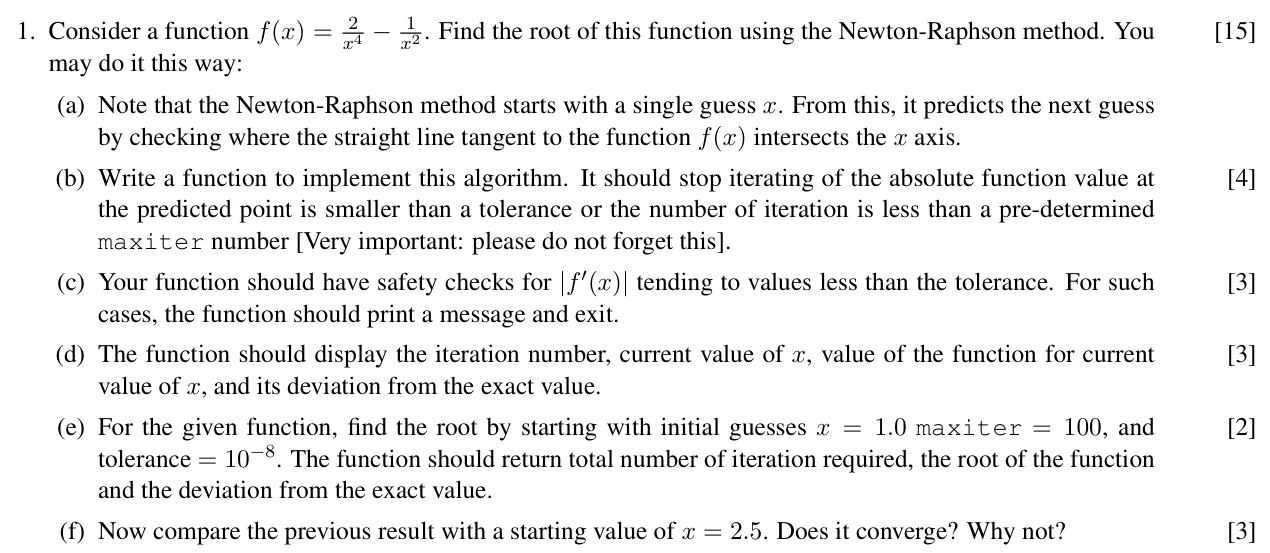

 we shall assume our domain is $x$>0. The analytical roots are 0, $\sqrt{2}$, $-\sqrt{2}$. 

In [2]:
#1
def f1(x):
    return 2/x**4 - 1/x**2

def df1(x):
    return -8/x**5 + 2/x**3




In [27]:
print('**Newton Rhapson Method**')
print()
def nwtn_rhps(f,df,tol,init_guess,exact,maxIter = 100):

    #====
    # f = f(x) whose root is required
    # df = df/dx 
    # tol = tolerance
    # maxIter = Maximum Iterations
    # init_guess = initial guess of root
    # exact = exact root
    #====

    a0 = init_guess 
    count = 0
    
    print('Iters\t x\t\tf(x)\t\tDeviation')
    #b0 = intvl[1]
    while (abs(f(a0)) > tol):
        count += 1
        if count != maxIter:
            #i.e if steps < maxIter

            x = a0 - f(a0)/df(a0)
            # deviation from exact root
            deviation = np.abs(x-exact)
            print(f'{count:3d}\t{x:.8f}\t{f(x):.8f}\t{deviation:.10f}')
            if abs(f(x)) < tol:
                # we got the root
                
        
                # print(f'The required root is {x:.8f}')
                # print(f'The value at root is {f(x):.8f}')
                # print(f'Converged after {count} iteration(s)')
                return x,deviation,count
                # break
            elif np.abs(df(x)) < tol:
                print('Warning! Flat function encountered\n Exiting ... ')
                return None
            else:
                a0 = x
        else:
            print(f'Maximum Iterations = {maxIter} reached!\n Result did not converge')
            return None


**Newton Rhapson Method**



In [34]:
tol = 10**(-8) #error
#initial guess
x0 = 1
maxIter = 100
exact = np.sqrt(2)
val = nwtn_rhps(f=f1,df=df1,tol=tol,init_guess=x0,exact=exact,maxIter = 100)

if val != None:
    root, error, iters = val
    print(f'\n\nThe required root is {root:.8f}')
    print(f'Converged after {iters} iteration(s)')
    print(f'Deviation from the exact value {error:.10f}')




Iters	 x		f(x)		Deviation
  1	1.16666667	0.34485631	0.2475468957
  2	1.30789474	0.09890640	0.1063188255
  3	1.39056219	0.01774161	0.0236513770
  4	1.41288320	0.00094381	0.0013303650
  5	1.41420919	0.00000309	0.0000043702
  6	1.41421356	0.00000000	0.0000000000


The required root is 1.41421356
Converged after 6 iteration(s)
Deviation from the exact value 0.0000000000


In [30]:
tol = 10**(-8) #error
#initial guess
x0 = 2.5
maxIter = 100
exact = np.sqrt(2)
val = nwtn_rhps(f=f1,df=df1,tol=tol,init_guess=x0,exact=exact,maxIter = 100)

if val != None:
    root, error, iters = val
    print(f'\n\nThe required root is {root:.8f}')
    print(f'Converged after {iters} iteration(s)')
    print(f'Deviation from the exact value {error:.10f}')


Iters	 x		f(x)		Deviation
  1	4.86111111	-0.03873668	3.4468975487
  2	7.53929844	-0.01697391	6.1250848798
  3	11.45162656	-0.00750916	10.0374129950
  4	17.26751101	-0.00333133	15.8532974472
  5	25.95996621	-0.00147945	24.5457526523
  6	38.97870018	-0.00065731	37.5644866138
  7	58.49377302	-0.00029210	57.0795594599
  8	87.75777538	-0.00012981	86.3435618175
  9	131.64806399	-0.00005769	130.2338504306
 10	197.47969375	-0.00002564	196.0654801905
 11	296.22460496	-0.00001140	294.8103913981
 12	444.34028341	-0.00000506	442.9260698491
 13	666.51267569	-0.00000225	665.0984621279
Warning! Flat function encountered
 Exiting ... 


So, the iteration didnt converge as it encountered a flat function

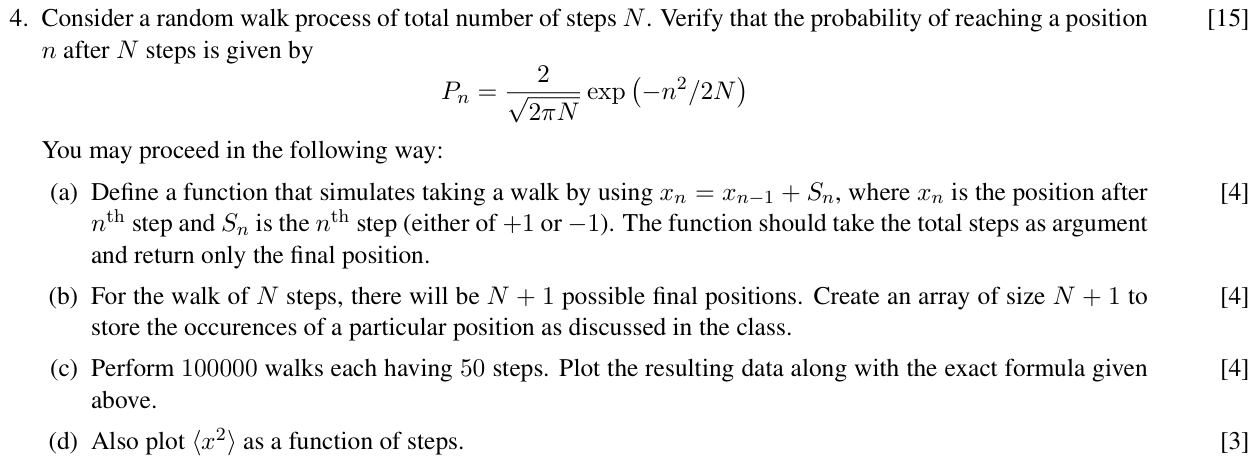

In [ ]:
def take_a_step():
    s = np.random.rand()
    if s > 0.5:
        return 1
    else:
        return -1

#function to update position after s steps
def post_update(s):
    #initializing walkers from 0
    finpos = 0
    for step in range(s):
        finpos += take_a_step()
    
    # such that for finpos +s = 0, finpos = -s it is at 1st position, and finpos = s,is the last position
    pos_in_array = int((finpos+s)/2.0)
    #print(finpos, pos_in_array)
    return pos_in_array

num_walkers = 100000

# total number of steps is N
num_step = 50

final_post_count = np.zeros(num_step+1)
# including 0

for walker in range(num_walkers):
    #iterating over each walker

    pos_in_array = post_update(s = num_step)
    #finds the final position of walker

    #storing the count of each position -- to plot bar chart
    final_post_count[pos_in_array] += 1

positions = np.linspace(-num_step, num_step, num_step+1)

In [51]:
n = np.arange(-num_step, num_step+1)

def Pn(N,ns):
    val = 2/(np.sqrt(2*np.pi*N))*np.exp(-ns**2/(2*N))
    return val

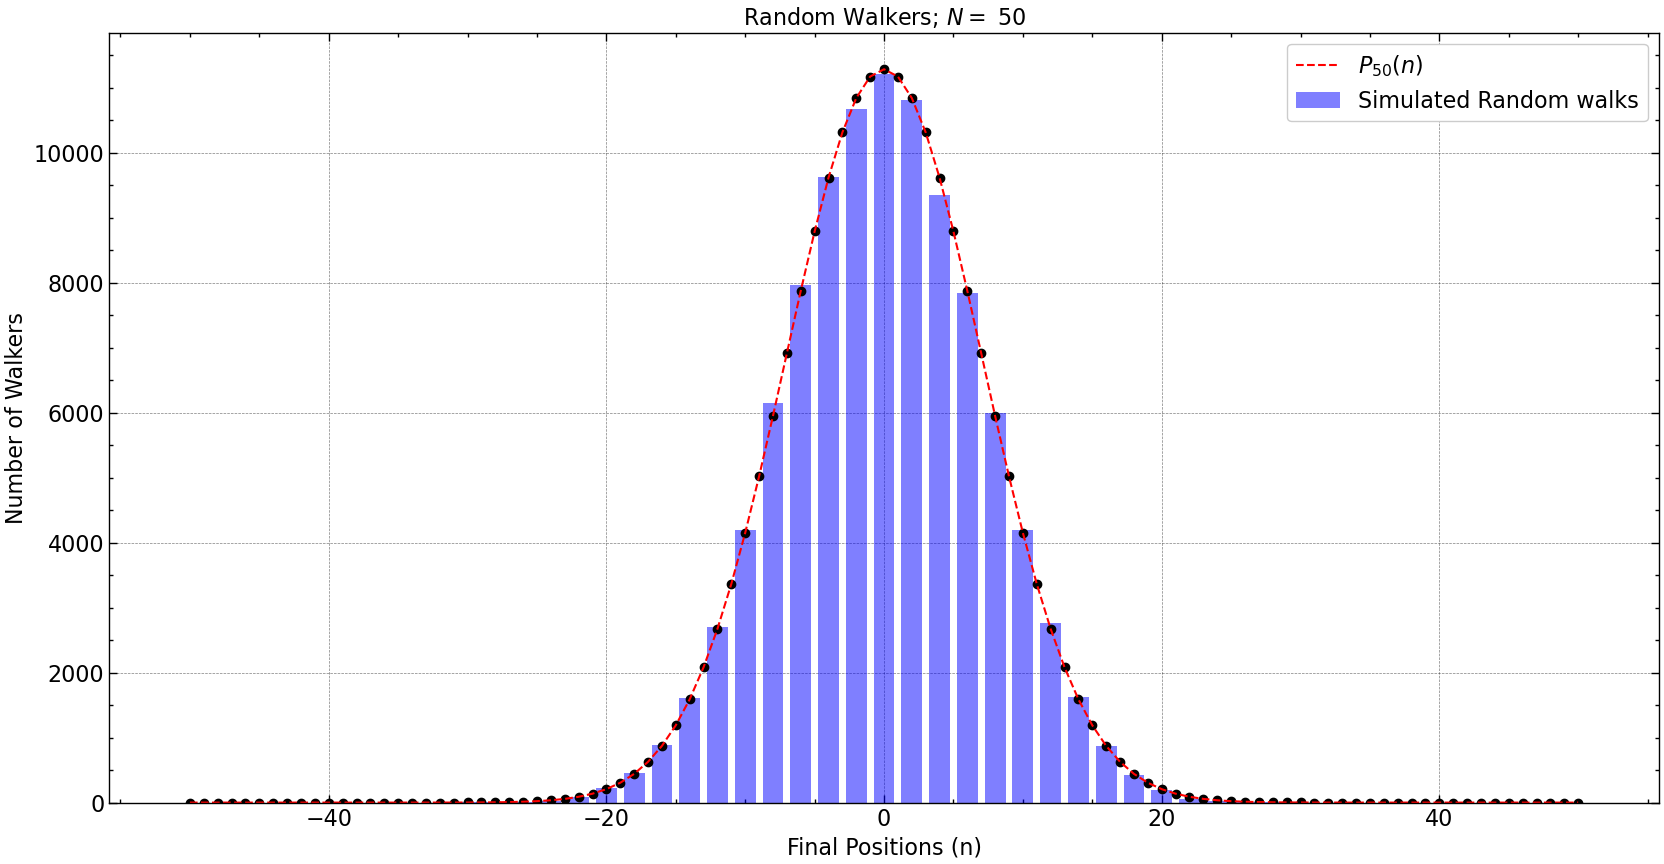

In [52]:

plt.figure(figsize=(20,10))
plt.title(f'Random Walkers; $N=$ {num_step}')
plt.xlabel('Final Positions (n)')
plt.ylabel('Number of Walkers')
plt.bar(positions, final_post_count, color= 'blue', alpha=0.5, width=1.5, label = 'Simulated Random walks')
plt.scatter(n,Pn(N = num_step, ns = n)*num_walkers,c='k')
plt.plot(n,Pn(N = num_step, ns = n)*num_walkers, color='red', lw=1.5,ls='dashed',label = '$P_{50}(n)$')
plt.legend(loc='upper right')

Its easy to observe that as we increase the number of walkers (order of magnitude wise), the distribution of the final position of all the walkers after sufficiently large $N$ steps, converges to the gaussian distribution centered at origin.

In [53]:
#4d

# total number of steps is N
N = num_step

sq_avg_post = np.zeros(N)
#array for storing positions of all walkers, starting from origin
xs = np.zeros(num_walkers)

for step in range(N):

    for walker in range(num_walkers):
        xi = take_a_step()
        xs[walker] += xi
    #updating after each step
    sq_avg_post[step] += np.mean(xs**2)
    # print(np.mean(xs**2))
steps = np.arange(1, N+1)

    

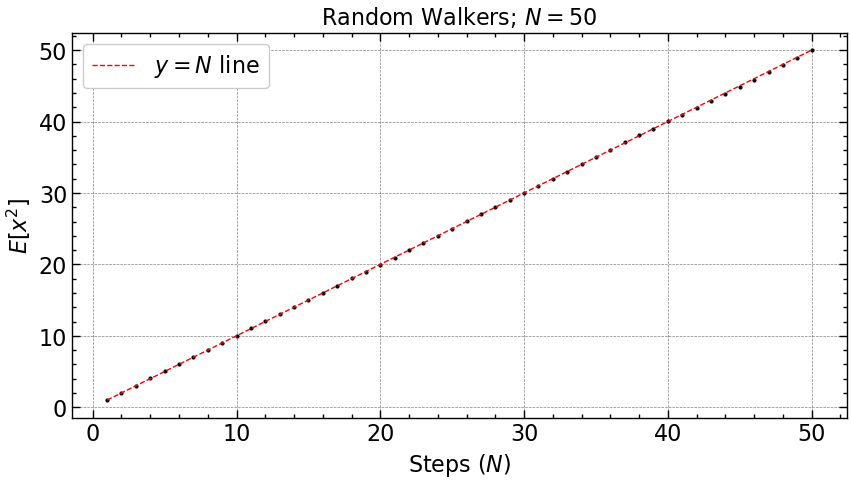

In [54]:
plt.figure(figsize=(10,5))
plt.title('Random Walkers; $N= 50$')
plt.xlabel('Steps $(N)$')
plt.ylabel(r'$E[x^2]$')
plt.plot(steps, steps,lw=1,ls='dashed',c='r', label = '$y= N$ line')
plt.scatter(steps, sq_avg_post,c='k',s=4)
plt.legend(loc='upper left')

Hence, we observe that $E[x^2]$ indeed converges to $N$, for large number of walkers $k \sim 10^5$ 


where, $N$ is the total number of steps by all the walkers

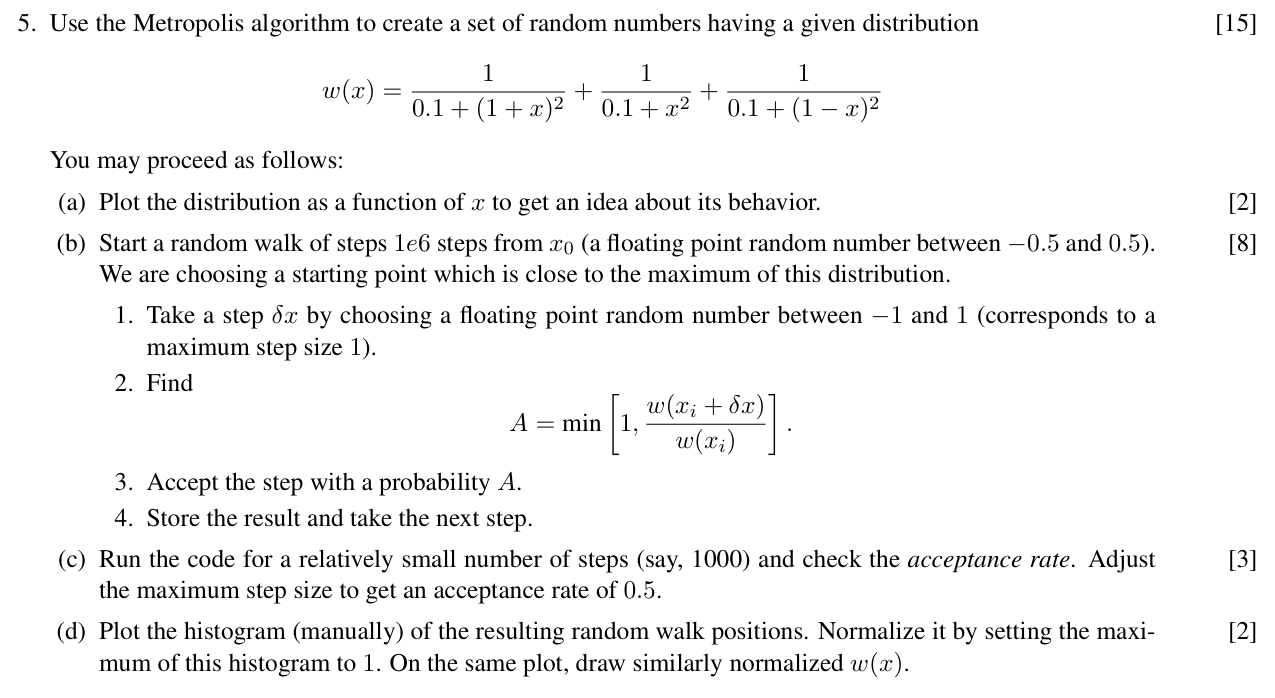

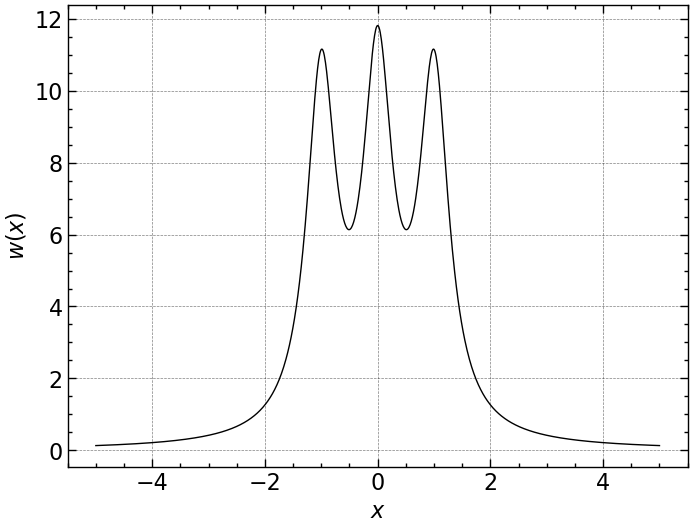

In [65]:
def w5(x):
    if abs(x) <= 5:
        func = 1/(0.1 + (1+x)**2) + 1/(0.1 + x**2) + 1/(0.1 + (1-x)**2)
        return func
    else:
        return 0

xs5 = np.linspace(-5,5,1000)
ys5 = [w5(x) for x in xs5]

plt.plot(xs5, ys5,lw=1,c='k')
plt.ylabel('$w(x)$')
plt.xlabel('$x$')

#normalising by setting maximum to 1
ys5n = ys5/np.max(ys5)

In [64]:
# numerically integrating to calculate the area
from scipy.integrate import quad
#integrating the given function form -5 to 5
area_exact = quad(w5,-5,5)
area_exact

# The return value is a tuple, with the first element 
# holding the estimated value of the integral and the 
# second element holding an estimate of the absolute integration error

(28.57230942739551, 2.8305006614113074e-07)

In [74]:
# Simulate

#starting point a random number between -0.5, 0.5
x0 = (np.random.random()-0.5)

#total steps
N = int(1e6)

#max stepsize
stepsize = 1

store = np.zeros(N)

#metropolis algorithm
for i in range(N):
    store[i] = x0 # set the starting point for ith step

    #x_1  = x_0 + \delta x
    # generate a step between -1, 1
    x1 = x0 + stepsize*(2*np.random.random()-1)
    # x1 = x0 + stepsize*(np.random.uniform(-1,1,1)[0])
    r = w5(x1)/w5(x0)
    if r>1:
        x0 = x1
    else:
        #evaluate the prob at the non success step
        p = np.random.rand()
        if p <= r:
            x0 = x1



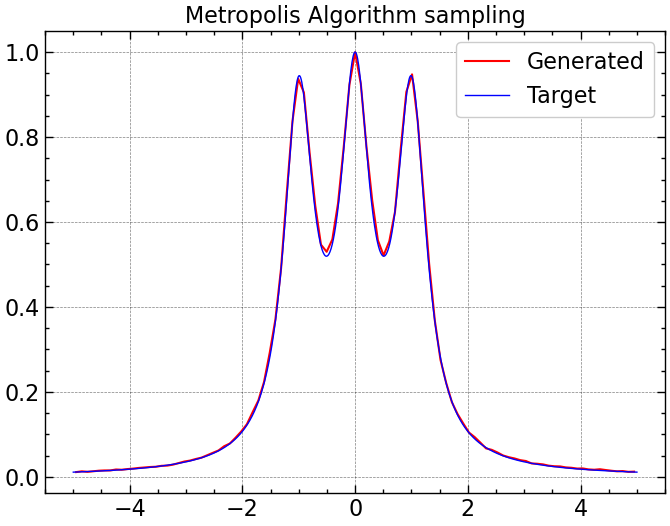

In [82]:
values, edges = np.histogram(store,99)
midpoints = [(edges[i]+edges[i+1])/2 for i in range(len(edges)-1)]
#normalising
values = values/np.max(values)

plt.title('Metropolis Algorithm sampling')
plt.plot(midpoints, values,label='Generated',lw=1.5, c='r')
plt.plot(xs5, ys5n,label='Target',lw=1,c='b')

plt.legend()

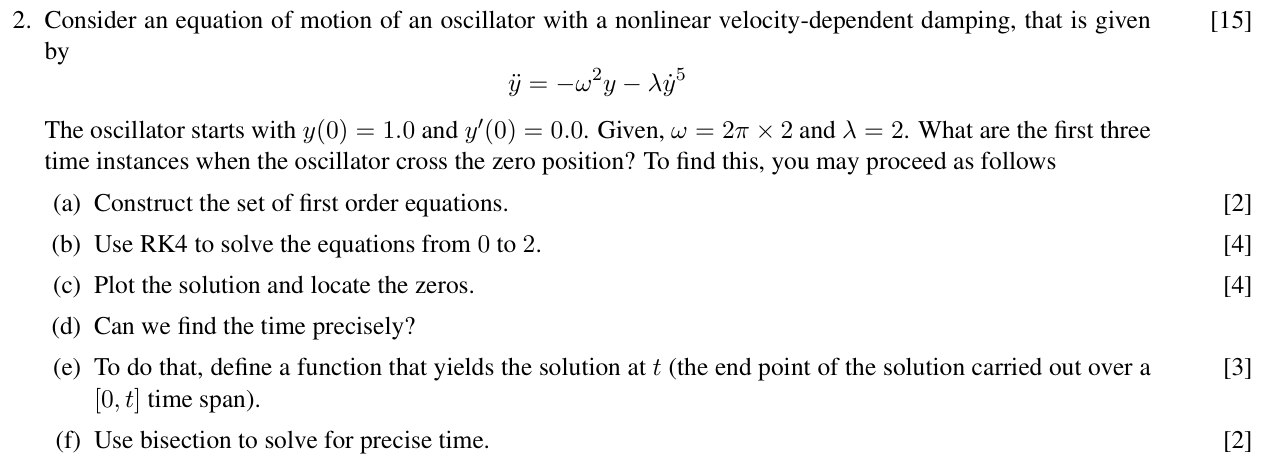

a)

$$ \frac{dy}{dt} = v$$
$$ \frac{dv}{dt} = -\omega^2 y - \lambda v^5$$

vector
$Y = [y,v]$

$$\frac{d}{dt}Y = G(Y,t)$$

In [185]:
#omega
w = 4*np.pi
lamb = 2
# define the slope vector g(x,Y)

def G(t,Y):
    val = np.asarray([Y[1],-(w**2)*Y[0] - lamb*(Y[1])**5])
    return val

In [186]:
#b

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def caller(my_method, fn, y0, x0,xf, h):
    # given initial value y0 = y(x0)
    y = y0 # initial value
    
    #Calculating N for given h
    N = int((xf-x0)/h)
    h = (xf-x0)/(N)
    # some cases endpoints are exactly not reached
    #array of x values
    xs = np.arange(x0,x0+N*h,h)
    
    # first creating null array for y values
    ys = np.zeros((len(xs), len(y0)), dtype=np.float64) 
    for i in range(len(xs)):
        x = xs[i]
        ys[i, :] = y 
        # at first call, first place-> y0 sit
        y = my_method(fn, x, y, h)
        
    return ys


# def caller_yv(Y_init,xs,N,h,v_ini,func,my_method):
#     ys=np.zeros(N)
#     vs=np.zeros(N)
#     ys[0]=Y_init
#     vs[0]=v_ini
#     for i in range(1,N):
#         x=xs[i]
#         ys[i],vs[i]=my_method(func,x,ys[i-1],vs[i-1],h)
#     return ys,vs

# def caller_nonsimplectic(my_method, func, Y_init,N, xs, h):
#     y = Y_init
#     ys = np.zeros((N, len(Y_init)))
#     for i in range(N):
#         x = xs[i]
#         ys[i, :] = y
#         y = my_method(func, x, y, h)
#     return ys

Initial conditions : $y(0) = 1$, $v(0) = 0$

In [ ]:
#omega
w = 4*np.pi
lamb = 2
tInit =0
tFinal = 2

#assuming a time step
h = 0.0001

#total iterations 
N = int((tFinal-tInit)/h)

#corrected time steps to include the endpoint
dt = (tFinal-tInit)/(N)

#time values
ts = np.arange(tInit,tInit+N*dt,dt)

y0 = 1
v0 = 0
# Initial condition
Y_init = np.asarray([y0, v0])  

# runge kutta solution

rk4Sol1 = caller(rk4,G,Y_init,tInit,tFinal,dt)
# returns an array of [y,p] values

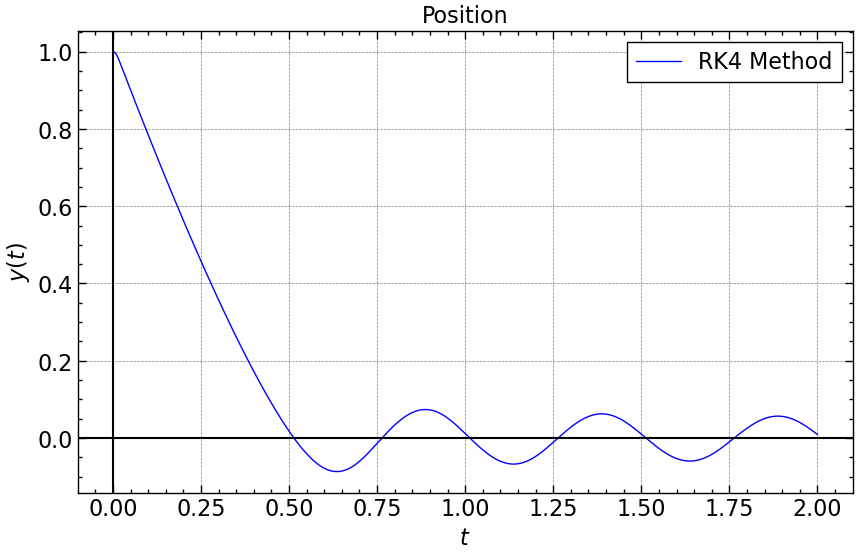

In [188]:
plt.figure(figsize=(10,6))
plt.title('Position')

plt.plot(ts,rk4Sol1[:,0],lw=1,label='RK4 Method',c='blue')
plt.axhline(y = 0, linestyle ="-", color = 'black', lw = 1.5)
plt.axvline(x = 0, linestyle ="-", color = 'black', lw = 1.5)
plt.xlabel('$t$')
plt.ylabel('$y(t)$')

plt.legend(fancybox=False, edgecolor = 'k',loc='upper right')

c) We locate the roots by noticing the change of sign in y values

In [189]:
#given 
def sign_change_indices(lst):
    return [i for i in range(len(lst) - 1) if lst[i] * lst[i + 1] < 0]

def discreteRootFinder(ys,xs,rootIntvl):
    # ====
    # ys -> array of y values in graph
    # xs -> array of y values in graph
    # rootIntvl = [a,b] such that we 
    # inspect visually from graph where all the roots lies between them
    # ==
    a,b = rootIntvl
    mask = np.where(((xs > a) & (xs < b) ))

    x_rootIntvl = xs[mask]
    y_rootIntvl = ys[mask]

    # Find where changes in sign occurs in y_rootIntvl
    indices = sign_change_indices(y_rootIntvl)
    roots = np.array([((x_rootIntvl[i] + x_rootIntvl[i+1])/2) for i in indices])
    return roots

print('\n The roots of y(t) are at times \n')
zeroes = discreteRootFinder(rk4Sol1[:,0],ts,rootIntvl = [0.5,1.8])
for t in zeroes:
    print(np.round(t,4),end='\n')




 The roots of y(t) are at times 

0.514
0.7636
1.0135
1.2634
1.5134
1.7633


In [221]:
def Bisection(f, intvl, eps, maxiter):
    """
    Implements the Bisection method to find a root of the function f in the interval [a, b]
    
    Parameters:
    f       : Function whose root is to be found
    intvl   : List or tuple containing the interval [a, b]
    eps     : Tolerance for stopping (absolute error)
    maxiter : Maximum number of iterations allowed

    Returns:
    root    : Estimated root of f
    count   : Number of iterations taken
    """
    a, b = intvl
    count = 1

    # Check if the interval is valid (i.e., root lies between a and b)
    if f(a) * f(b) > 0:
        print("Bad interval!")
        return None, count

    # Check if endpoints themselves are roots
    if abs(f(a)) < eps:
        return a, count
    elif abs(f(b)) < eps:
        return b, count

    # Begin iteration
    while abs(b - a) > eps and count < maxiter:
        ## convergence criteria based on the distance between interval
        mid = 0.5 * (a + b)
        f_mid = f(mid)

        if abs(f_mid) < eps:
            return mid, count

        # Determine in which half the root lies
        if f(a) * f_mid < 0:
            b = mid  # Root lies in [a, mid]
        else:
            a = mid  # Root lies in [mid, b]

        count += 1

    # Final check after loop exit
    mid = 0.5 * (a + b)
    if abs(f(mid)) < eps:
        return mid, count

    # If max iterations exceeded
    print("It does not converge within the max iteration limit!")
    return None, count
    


The time can be found precisely by employing the rk4 as a function form of $t$

In [224]:
def rk4Solt(t):
    if ((t>=tInit) and (t<= tFinal)):
        h = 0.0001
        N = int((t-tInit)/h)
        #corrected time steps to include the endpoint
        dt = (t-tInit)/(N)
        solution = caller(rk4,G,Y_init,tInit,t,dt)
        #returns yval at the last t
        return solution[:,0][-1]
# list of intervals
RootIntvls = np.array([[0.5,0.6],[0.74,0.77],[1,1.1],[1.24,1.3],[1.5,1.6],[1.7,1.8]])
zeroes = []
print('The precise zeroes are: \n\n')
for intvl in RootIntvls:
    # print(intvl)
    result = Bisection(f=rk4Solt, intvl=intvl, eps=1e-6, maxiter=100)
    if result is not None:
        time, cnt = result
        zeroes.append(time)
        print(time,end='\n')
    else:
        print("Bisection failed for interval", intvl)
    

The precise zeroes are: 


0.5141220092773439
0.763642578125
1.0135101318359374
1.2634484863281248
1.5134124755859375
1.7633880615234374


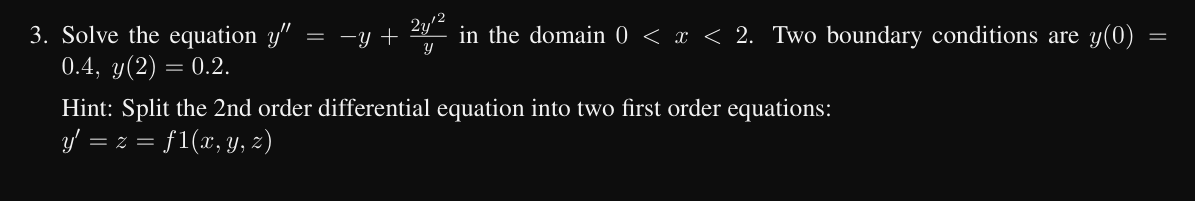
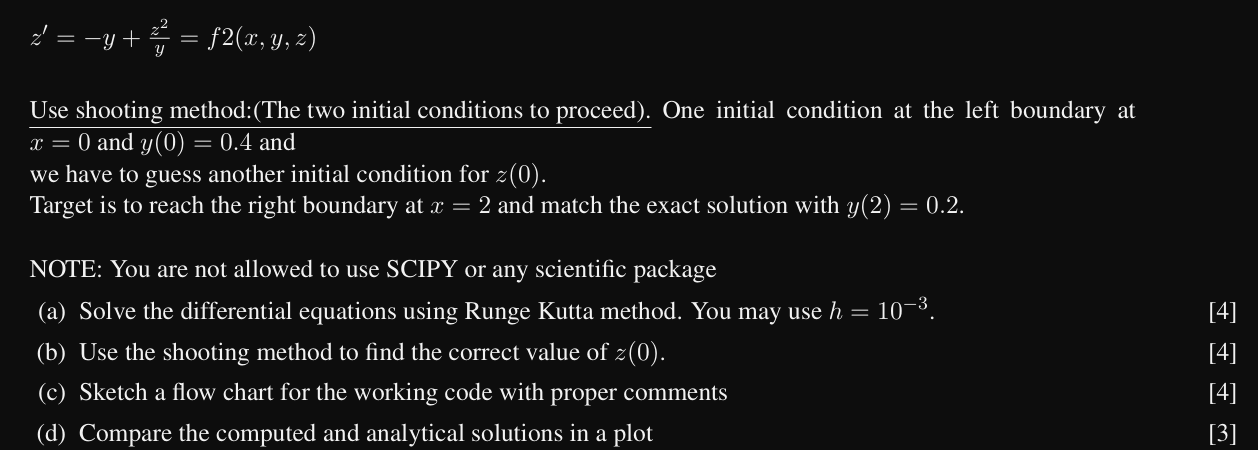

a)
$$y'' = -y + 2 \frac{y'^2}{y}$$
$$ \frac{dy}{dx} = v$$
$$ \frac{dv}{dx} = -y + 2 \frac{v^2}{y}$$

$Y = [y, v]$

$$\frac{d}{dt}Y = B(x,Y)$$

Initial boundary values:
$y(0) = 0.4, y(2) = 0.2, v(0) = ?$

In [227]:
def B(x,Y):
    val = np.asarray([Y[1],-Y[0] + 2*(Y[1]**2)/Y[0]])
    return val

#a

# The following is a caller function. It integrates f from xlim[0] to xlim[1] with initial condition yini. 
# The parameter k is included in the argument along with the number of points N.
def caller_rk4(f,yini,guess,N,xlim):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    y[1]=guess
    ys = np.zeros((N,len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y,h)
    return xs, ys

def secant(guesses,f,method,ybound):
    guess1, guess2 = guesses
    iter = 0
    while abs(method(guess2,f,ybound))>tol and iter<maxiter:
        f1 = method(guess1,f,ybound)
        f2 = method(guess2,f,ybound)
        guess1, guess2 = guess2, (f2*guess1 - f1*guess2)/(f2 - f1)
        iter += 1
    if iter == maxiter:
        return iter, None
    else:
        return iter, guess2
    
def score(guess,f,ybound):
    xs, ys = caller_rk4(f,Y_init,guess,N,xlim)
    return ys[-1][0] - ybound[1]


In [230]:
# boundary points
xlim = [0, 2]
#boundaries
Y_init= [0.4 , 0.2]
ybound = [0.4, 0.2]
# starting to shoot from this point i.e Y(0) = [y(0), <any guess of slope = v(0)+/->]
Y0 = [Y_init[0], 0.01]
# Number of points
N = 301

# Max iteration and tolerance for secant
maxiter = 50
tol = 1.0e-6

In [231]:
guesses = np.linspace(-3.0,2.5,500);
scores = [score(guess,B,ybound) for guess in guesses]

C:\Users\hello\AppData\Local\Temp\ipykernel_5536\3492236704.py:2: RuntimeWarning: overflow encountered in scalar power
  val = np.asarray([Y[1],-Y[0] + 2*(Y[1]**2)/Y[0]])
C:\Users\hello\AppData\Local\Temp\ipykernel_5536\3492236704.py:2: RuntimeWarning: invalid value encountered in scalar divide
  val = np.asarray([Y[1],-Y[0] + 2*(Y[1]**2)/Y[0]])
C:\Users\hello\AppData\Local\Temp\ipykernel_5536\3492236704.py:2: RuntimeWarning: overflow encountered in scalar multiply
  val = np.asarray([Y[1],-Y[0] + 2*(Y[1]**2)/Y[0]])


(0.0, 0.5)

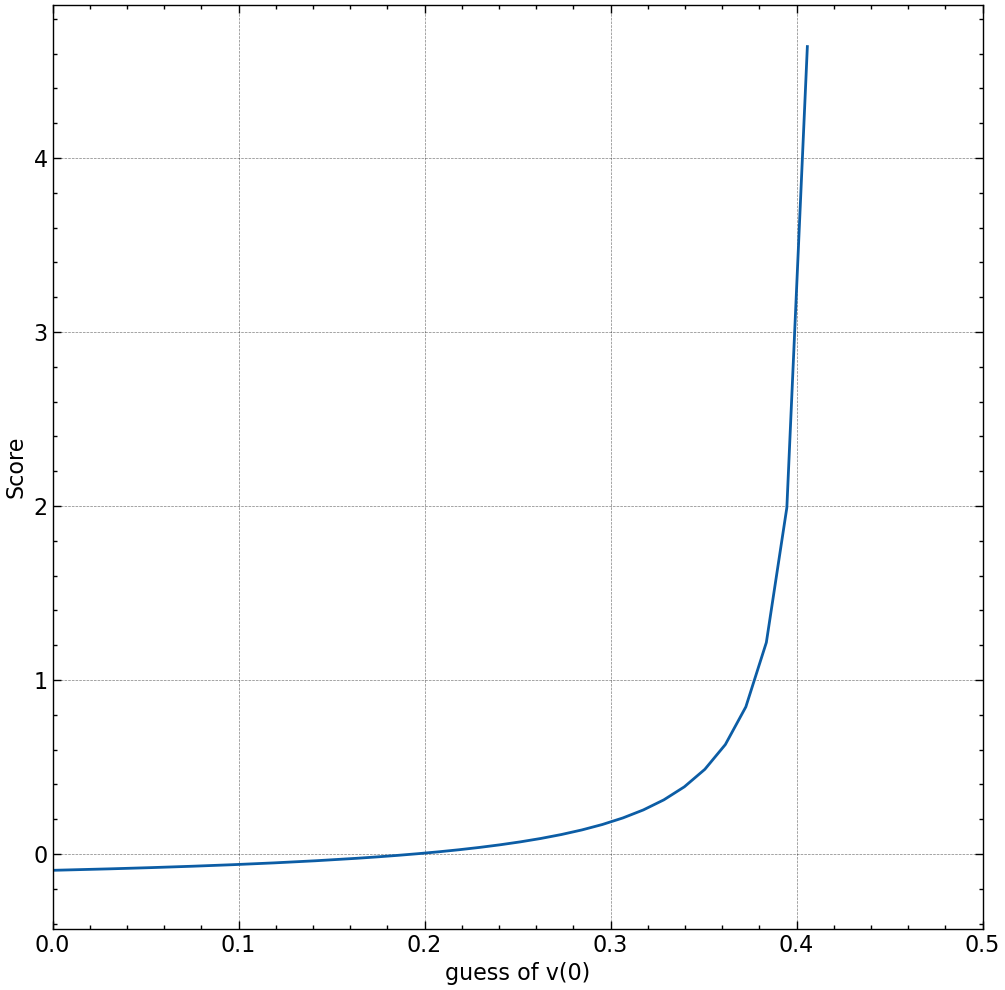

In [233]:
plt.figure(figsize=(12, 12))
plt.plot(guesses, scores,lw=2);

plt.xlabel("guess of v(0)")
plt.ylabel("Score")
plt.xlim(0,0.5)

In [237]:
guesses=[0.1,0.3]
iter,best_guess=secant(guesses,B,score,ybound)
# finding the best guess where score = 0
print('The value of v(0) as calculcated using shooting method is:')
best_guess

The value of v(0) as calculcated using shooting method is:


0.19434945372202542

In [239]:
xs3, ys3 = caller_rk4(B,Y_init,best_guess,200,xlim)

Text(0, 0.5, 'y(x)')

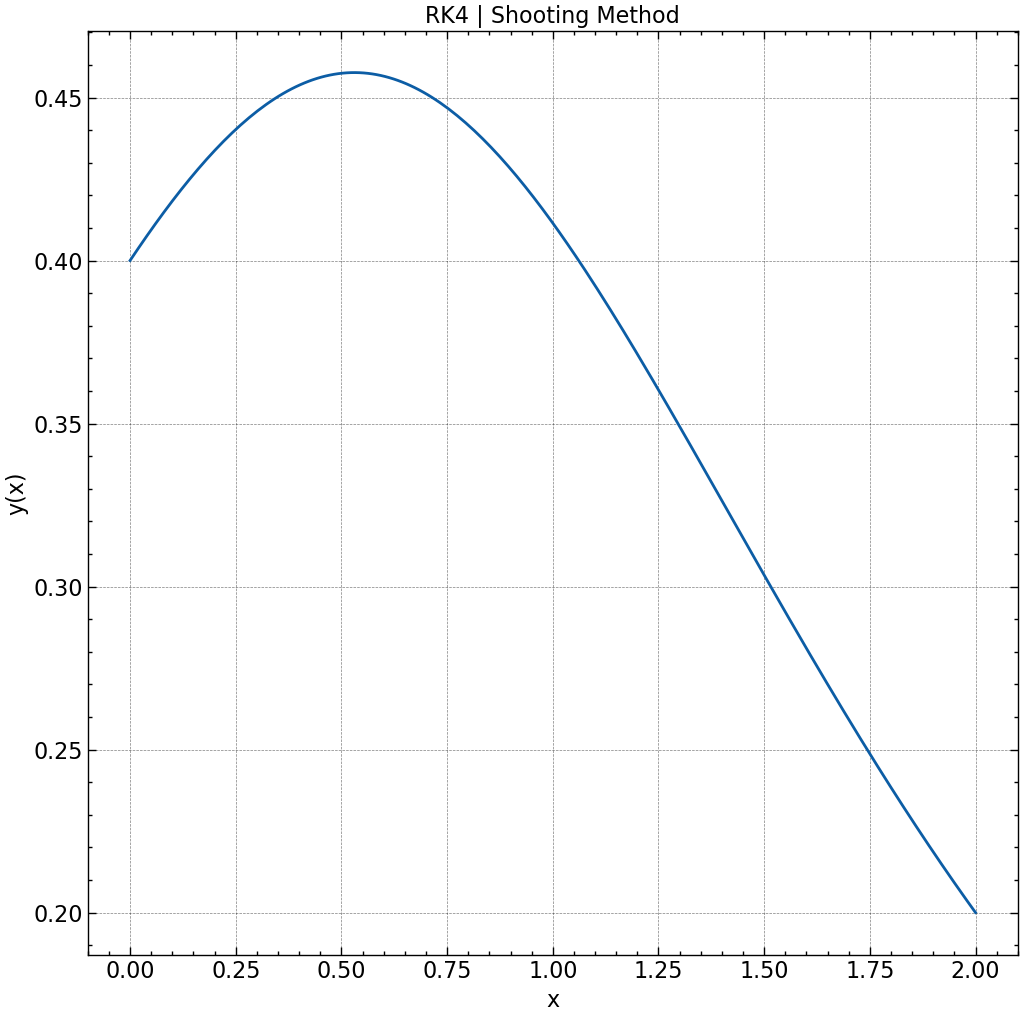

In [242]:
plt.figure(figsize=(12, 12))
plt.plot(xs3, ys3[:,0])
#plt.plot(times, ysR[:, 1], label="Velocity")
plt.title("RK4 | Shooting Method")
plt.xlabel("x")
plt.ylabel("y(x)")


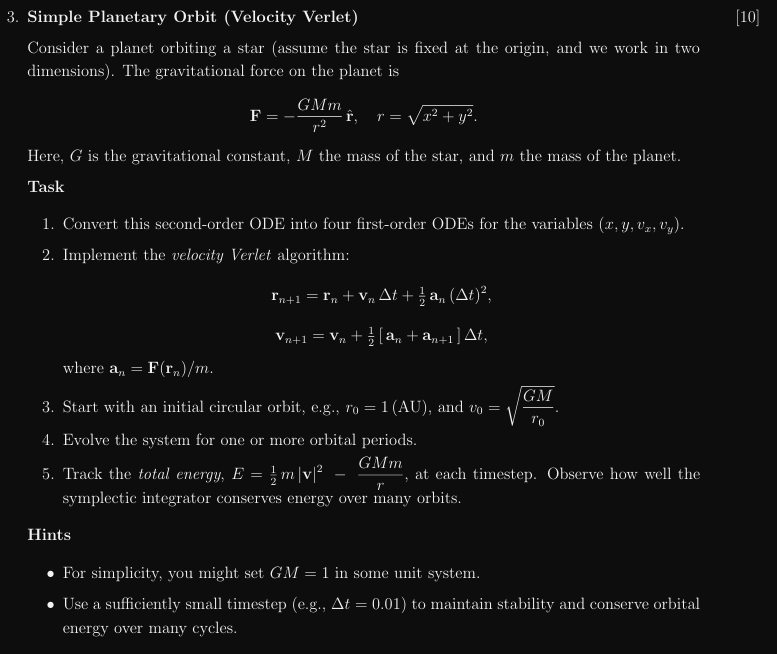

# 1
### Diferrential equations in x- direction:

$$\frac{dv_{x}}{dt}=-\frac{GMx}{(x^{2}+y^{2})^{3/2}} $$  
 $$\frac{dx}{dt}= v_{x}$$ 

### Differential Equations in y- direction

$$\frac{dy}{dt}= v_{y}$$ 
 $$\frac{dv_{x}}{dt}=-\frac{GMy}{(x^{2}+y^{2})^{3/2}} $$

$GM  =1$

In [244]:
# velocity verlet

def velocity_verlet(func,t,yn,vny,xn,vnx,h):
    #calculating radial distance
    rn=((yn**2)+(xn**2))**(0.5) 

    #storing accelerations in respective directions
    a0_y=func(t,yn,rn)
    a0_x=func(t,xn,rn) 

    #calculating immediate displacement for next timestep
    y_next=yn+(vny*h)+(0.5*a0_y*(h**2))
    x_next=xn+(vnx*h)+(0.5*a0_x*(h**2)) 

    #calculating radius for new displacements
    r_next=((y_next**2)+(x_next**2))**(0.5) 
    #evaluating velocities at end of next timestep
    vy_next=vny+(0.5*(a0_y+func(t+h,y_next,r_next))*h)
    vx_next=vnx+(0.5*(a0_x+func(t+h,x_next,r_next))*h) 
    return y_next,vy_next,x_next,vx_next #returning results

def caller_yv(y_ini,x_ini,ts,N,h,vy_ini,vx_ini,func,my_method):
    ys=np.zeros(N)
    xs=np.zeros(N)
    vys=np.zeros(N)
    vxs=np.zeros(N) #setting up empty arrays
    ys[0]=y_ini
    vys[0]=vy_ini
    xs[0]=x_ini
    vxs[0]=vx_ini #setting up initial conditions
    for i in range(1,N):
        t=ts[i]
        ys[i],vys[i],xs[i],vxs[i]=my_method(func,t,ys[i-1],vys[i-1],xs[i-1],vxs[i-1],h) # calculating arrays
    return ys,vys,xs,vxs #returning results

def acc(t,xy,r):
    #defining acceleration function
    return ((-1)*xy/(r**3)) 
#setting up parameters
dt=0.01
t_init=0.0
t_fin=30.0 
 #calculating number of steps
N=int((abs(t_fin-t_init))/dt)
#setting up time array
times = np.arange(t_init, t_init + N*dt, dt) 
#initial conditions
y_ini=0.0
x_ini=1.0
vx_ini=0.0
vy_ini=1.0 #declaring initial conditions

ysVelVer,vysVelVer,xsVelVer,vxsVelVer=caller_yv(y_ini,x_ini,times,N,dt,vy_ini,vx_ini,acc,velocity_verlet) 
#evaluating trajectory


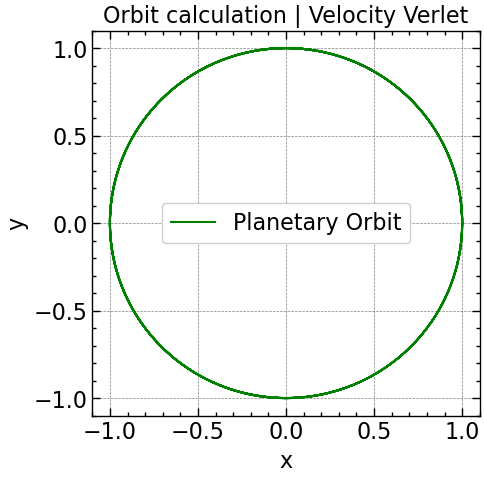

In [248]:
plt.figure(figsize=(5, 5))
plt.title("Orbit calculation | Velocity Verlet")
#Plotting trajectory
plt.plot(xsVelVer, ysVelVer,label="Planetary Orbit",lw=1.5,c='g')
plt.xlabel("x")
plt.ylabel("y")

plt.legend() 


Text(0.5, 0, 't')

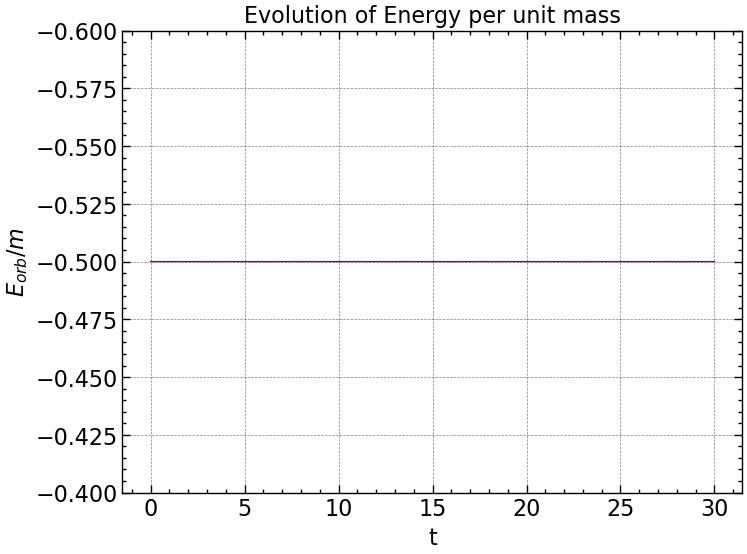

In [ ]:
OrbitalEnergy = 0.5*(vxsVelVer**2 + vysVelVer**2) - (xsVelVer**2 + ysVelVer**2)**(-0.5)
plt.title('Evolution of Energy per unit mass')
plt.plot(times,OrbitalEnergy,lw=1,c='purple')
plt.ylabel(r"$E_{orb}/m$")
plt.ylim((-0.4,-0.6))
plt.xlabel('t')
#this constancy shows how well the energy is conserved by this algo!
